In [40]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
plt.rc('font',family='Times New Roman')

masking_forget_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsmasking/forget_acc.npy'
masking_remain_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsmasking/remain_acc.npy'

# 导入数据
masking_forget = np.load(masking_forget_path)
masking_remain = np.load(masking_remain_path)
# 在masking_forget中加入一个零，放到第一个位置
masking_forget = np.insert(masking_forget, 0, 0)
masking_remain = np.insert(masking_remain, 0, 74.76236899829394)

lora_forget_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsr8-lr1e-4/forget_acc.npy'
lora_remain_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsr8-lr1e-4/remain_acc.npy'



# 导入数据
lora_forget = np.load(lora_forget_path)
lora_remain = np.load(lora_remain_path)

lora_forget = np.insert(lora_forget, 0, lora_forget[0])
lora_remain = np.insert(lora_remain, 0, lora_remain[0])

# rank 64
lora_forget64_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsr64-lr1e-4/forget_acc.npy'
lora_remain64_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsr64-lr1e-4/remain_acc.npy'

# 导入数据
lora_forget64 = np.load(lora_forget64_path)
lora_remain64 = np.load(lora_remain64_path)

lora_forget64 = np.insert(lora_forget64, 0, lora_forget64[0])
lora_remain64 = np.insert(lora_remain64, 0, lora_remain64[0])

# baseline，是一个761长度的全为74.63的数组
baseline_forget = np.ones(761) * 73.78
baseline_remain = np.ones(761) * 74.63

In [34]:
length = len(masking_forget)
length #761
len(masking_remain) #761

761

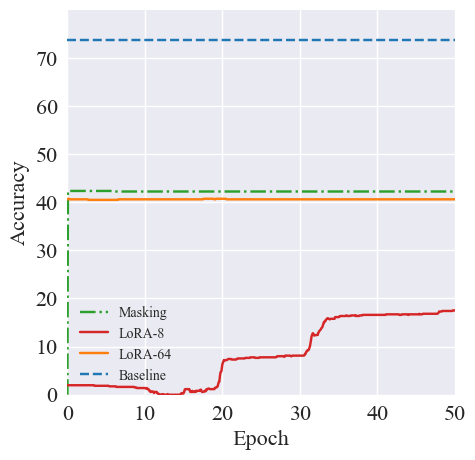

In [55]:
# 绘制图像
plt.figure(figsize=(5, 5))
x = np.linspace(0, 50, len(lora_forget))
plt.xlim(0, 50)
plt.ylim(0, 80)
plt.xlabel('Epoch',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
# 设置坐标轴刻度
my_x_ticks = np.arange(0, 51, 10)
my_y_ticks = np.arange(0, 71, 10)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
# 修改坐标轴刻度字体大小
plt.tick_params(labelsize=16)
plt.plot(x, masking_forget, label='Masking', color='#2ca02c',linestyle='-.')
plt.plot(x, lora_forget, label='LoRA-8', color='#d62728')
plt.plot(x, lora_forget64, label='LoRA-64', color='#ff7f0e')
plt.plot(x, baseline_forget, label='Baseline', color='#1f77b4', linestyle='--')
plt.legend(loc='best')
plt.savefig('forget.pdf', bbox_inches='tight', dpi=1200)

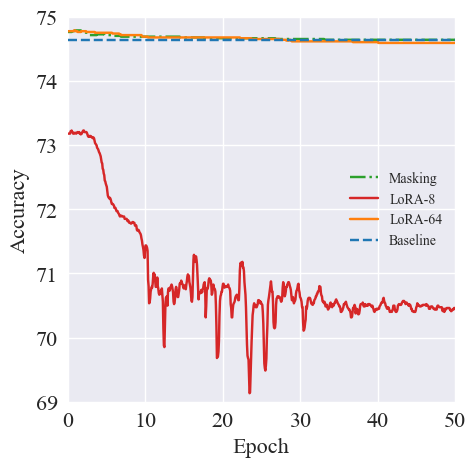

In [60]:
# 绘制图像
plt.figure(figsize=(5, 5))
x = np.linspace(0, 50, len(lora_forget))
plt.xlim(0, 50)
plt.ylim(69, 75)
plt.xlabel('Epoch',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
# 设置坐标轴刻度
my_x_ticks = np.arange(0, 51, 10)
# my_y_ticks = np.arange(0, 71, 10)
plt.xticks(my_x_ticks)
# plt.yticks(my_y_ticks)
# 修改坐标轴刻度字体大小
plt.tick_params(labelsize=16)
plt.plot(x, masking_remain, label='Masking', color='#2ca02c',linestyle='-.')
plt.plot(x, lora_remain, label='LoRA-8', color='#d62728')
plt.plot(x, lora_remain64, label='LoRA-64', color='#ff7f0e')
plt.plot(x, baseline_remain, label='Baseline', color='#1f77b4', linestyle='--')
plt.legend(loc='best')
plt.savefig('remain.pdf', bbox_inches='tight', dpi=1200)